In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import os

# Find the exact file path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ahmedshahriarsakib/usa-real-estate-dataset/realtor-data.zip.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ahmedshahriarsakib/usa-real-estate-dataset/realtor-data.zip.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()


Shape: (2226382, 12)

Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']

First few rows:


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [3]:
# Filter to our 5 target Section 8 cities
target_cities = {
    'Memphis': 'Tennessee',
    'Cleveland': 'Ohio',
    'Baltimore': 'Maryland',
    'Detroit': 'Michigan',
    'Atlanta': 'Georgia'
}

filtered_dfs = []
for city, state in target_cities.items():
    city_df = df[(df['city'] == city) & (df['state'] == state)]
    print(f"{city}, {state}: {len(city_df)} listings")
    filtered_dfs.append(city_df)

section8_df = pd.concat(filtered_dfs)
print(f"\nTotal listings across all 5 cities: {len(section8_df)}")
print(f"\nFor sale only: {len(section8_df[section8_df['status'] == 'for_sale'])}")


Memphis, Tennessee: 2305 listings
Cleveland, Ohio: 3405 listings
Baltimore, Maryland: 7150 listings
Detroit, Michigan: 2081 listings
Atlanta, Georgia: 7109 listings

Total listings across all 5 cities: 22050

For sale only: 13023


In [4]:
# HUD Fair Market Rents 2024 by city (2BR - standard Section 8 unit)
# Source: HUD.gov Fair Market Rents 2024
hud_fmr = {
    'Memphis':    {'fmr_1br': 1012, 'fmr_2br': 1175, 'fmr_3br': 1549},
    'Cleveland':  {'fmr_1br': 1052, 'fmr_2br': 1267, 'fmr_3br': 1598},
    'Baltimore':  {'fmr_1br': 1497, 'fmr_2br': 1808, 'fmr_3br': 2289},
    'Detroit':    {'fmr_1br': 1050, 'fmr_2br': 1275, 'fmr_3br': 1625},
    'Atlanta':    {'fmr_1br': 1392, 'fmr_2br': 1649, 'fmr_3br': 2101},
}

# Property tax rates by city (annual % of property value)
property_tax_rates = {
    'Memphis':   0.0194,  # 1.94%
    'Cleveland': 0.0262,  # 2.62%
    'Baltimore': 0.0222,  # 2.22%
    'Detroit':   0.0383,  # 3.83% — highest in the list
    'Atlanta':   0.0083,  # 0.83% — lowest in the list
}

print("HUD Fair Market Rents 2024:")
for city, rents in hud_fmr.items():
    print(f"  {city}: 1BR ${rents['fmr_1br']}/mo | 2BR ${rents['fmr_2br']}/mo | 3BR ${rents['fmr_3br']}/mo")

print("\nProperty Tax Rates:")
for city, rate in property_tax_rates.items():
    print(f"  {city}: {rate*100:.2f}%")

HUD Fair Market Rents 2024:
  Memphis: 1BR $1012/mo | 2BR $1175/mo | 3BR $1549/mo
  Cleveland: 1BR $1052/mo | 2BR $1267/mo | 3BR $1598/mo
  Baltimore: 1BR $1497/mo | 2BR $1808/mo | 3BR $2289/mo
  Detroit: 1BR $1050/mo | 2BR $1275/mo | 3BR $1625/mo
  Atlanta: 1BR $1392/mo | 2BR $1649/mo | 3BR $2101/mo

Property Tax Rates:
  Memphis: 1.94%
  Cleveland: 2.62%
  Baltimore: 2.22%
  Detroit: 3.83%
  Atlanta: 0.83%


In [5]:
# Filter for sale only and clean the data
for_sale = section8_df[section8_df['status'] == 'for_sale'].copy()

# Drop rows missing critical fields
for_sale = for_sale.dropna(subset=['price', 'bed', 'city'])

# Remove outliers — keep properties between $30K and $800K
for_sale = for_sale[(for_sale['price'] >= 30000) & (for_sale['price'] <= 800000)]

# Round beds to nearest whole number and cap at 4
for_sale['bed'] = for_sale['bed'].clip(1, 4).round().astype(int)

print(f"Clean listings to analyze: {len(for_sale)}")
print(f"\nListings per city:")
print(for_sale['city'].value_counts())
print(f"\nPrice range: ${for_sale['price'].min():,.0f} — ${for_sale['price'].max():,.0f}")
print(f"Average price: ${for_sale['price'].mean():,.0f}")

Clean listings to analyze: 10645

Listings per city:
city
Baltimore    3078
Atlanta      2604
Memphis      1910
Detroit      1579
Cleveland    1474
Name: count, dtype: int64

Price range: $30,000 — $800,000
Average price: $245,675


In [6]:
def calculate_roi(row, hud_fmr, property_tax_rates):
    city = row['city']
    price = row['price']
    beds = int(row['bed'])
    
    # Get the right FMR based on bedroom count
    if beds == 1:
        monthly_rent = hud_fmr[city]['fmr_1br']
    elif beds == 2:
        monthly_rent = hud_fmr[city]['fmr_2br']
    else:
        monthly_rent = hud_fmr[city]['fmr_3br']
    
    # Annual gross rent
    annual_rent = monthly_rent * 12
    
    # Annual property tax
    annual_tax = price * property_tax_rates[city]
    
    # Estimated annual expenses (maintenance 1%, insurance 0.5%, vacancy 5%)
    maintenance = price * 0.01
    insurance = price * 0.005
    vacancy_loss = annual_rent * 0.05
    
    # Annual net income
    annual_expenses = annual_tax + maintenance + insurance + vacancy_loss
    annual_net = annual_rent - annual_expenses
    
    # Monthly cash flow
    monthly_cashflow = annual_net / 12
    
    # ROI % (assuming 20% down payment)
    down_payment = price * 0.20
    closing_costs = price * 0.03
    total_invested = down_payment + closing_costs
    roi_pct = (annual_net / total_invested) * 100
    
    return pd.Series({
        'monthly_rent': monthly_rent,
        'monthly_cashflow': round(monthly_cashflow, 2),
        'annual_net': round(annual_net, 2),
        'roi_pct': round(roi_pct, 2),
        'annual_tax': round(annual_tax, 2),
        'total_invested': round(total_invested, 2)
    })

# Apply to all listings
roi_results = for_sale.apply(
    lambda row: calculate_roi(row, hud_fmr, property_tax_rates), axis=1
)
for_sale = pd.concat([for_sale, roi_results], axis=1)

print("ROI calculated for all listings!")
print(f"\nAverage ROI by city:")
print(for_sale.groupby('city')['roi_pct'].mean().round(2).sort_values(ascending=False))
print(f"\nAverage monthly cash flow by city:")
print(for_sale.groupby('city')['monthly_cashflow'].mean().round(2).sort_values(ascending=False))

ROI calculated for all listings!

Average ROI by city:
city
Detroit      73.01
Cleveland    61.49
Baltimore    52.96
Memphis      45.54
Atlanta      18.41
Name: roi_pct, dtype: float64

Average monthly cash flow by city:
city
Baltimore    1304.51
Atlanta      1014.39
Cleveland     915.26
Detroit       860.52
Memphis       844.66
Name: monthly_cashflow, dtype: float64


In [7]:
# Appreciation potential scores based on market research
# Scale 1-10 (10 = highest appreciation potential)
appreciation_scores = {
    'Memphis':   6.5,
    'Cleveland': 6.0,
    'Baltimore': 7.5,
    'Detroit':   8.5,  # massive revitalization upside
    'Atlanta':   9.0,  # strongest appreciation market
}

# Section 8 voucher demand vs supply score (1-10)
# Based on HUD waitlist data and voucher utilization rates
voucher_demand_scores = {
    'Memphis':   8.5,
    'Cleveland': 7.5,
    'Baltimore': 9.0,  # massive waitlist, high demand
    'Detroit':   8.0,
    'Atlanta':   8.5,
}

# Add scores to dataframe
for_sale['appreciation_score'] = for_sale['city'].map(appreciation_scores)
for_sale['voucher_demand_score'] = for_sale['city'].map(voucher_demand_scores)

# Calculate composite investment score (weighted)
# ROI 40%, Appreciation 25%, Voucher Demand 20%, Cash Flow 15%
for_sale['roi_normalized'] = (for_sale['roi_pct'] / for_sale['roi_pct'].max()) * 10
for_sale['cashflow_normalized'] = (for_sale['monthly_cashflow'] / for_sale['monthly_cashflow'].max()) * 10

for_sale['investment_score'] = (
    for_sale['roi_normalized'] * 0.40 +
    for_sale['appreciation_score'] * 0.25 +
    for_sale['voucher_demand_score'] * 0.20 +
    for_sale['cashflow_normalized'] * 0.15
).round(2)

# Assign letter grades
def assign_grade(score):
    if score >= 8.0:   return 'A'
    elif score >= 7.0: return 'B'
    elif score >= 6.0: return 'C'
    elif score >= 5.0: return 'D'
    else:              return 'F'

for_sale['grade'] = for_sale['investment_score'].apply(assign_grade)

print("Investment grades assigned!")
print(f"\nGrade distribution by city:")
print(for_sale.groupby(['city', 'grade']).size().unstack(fill_value=0))
print(f"\nTop 10 individual properties:")
top10 = for_sale.nlargest(10, 'investment_score')[
    ['city', 'price', 'bed', 'monthly_rent', 'monthly_cashflow', 'roi_pct', 'investment_score', 'grade']
]
print(top10.to_string())

Investment grades assigned!

Grade distribution by city:
grade       A    B    C     D     F
city                               
Atlanta     0    2   28   925  1649
Baltimore  75  103  265  1200  1435
Cleveland   0    0   43   255  1176
Detroit     0   45  250   658   626
Memphis     0    0   50   305  1555

Top 10 individual properties:
             city    price  bed  monthly_rent  monthly_cashflow  roi_pct  investment_score grade
230018  Baltimore  30000.0    3        2289.0           2081.55   362.01              9.18     A
230133  Baltimore  30000.0    3        2289.0           2081.55   362.01              9.18     A
230160  Baltimore  30000.0    3        2289.0           2081.55   362.01              9.18     A
230235  Baltimore  30000.0    3        2289.0           2081.55   362.01              9.18     A
230315  Baltimore  30000.0    3        2289.0           2081.55   362.01              9.18     A
230316  Baltimore  30000.0    3        2289.0           2081.55   362.01      

/tmp/ipykernel_55/2690677184.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(city_order, rotation=20)
/tmp/ipykernel_55/2690677184.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(city_order, rotation=20)


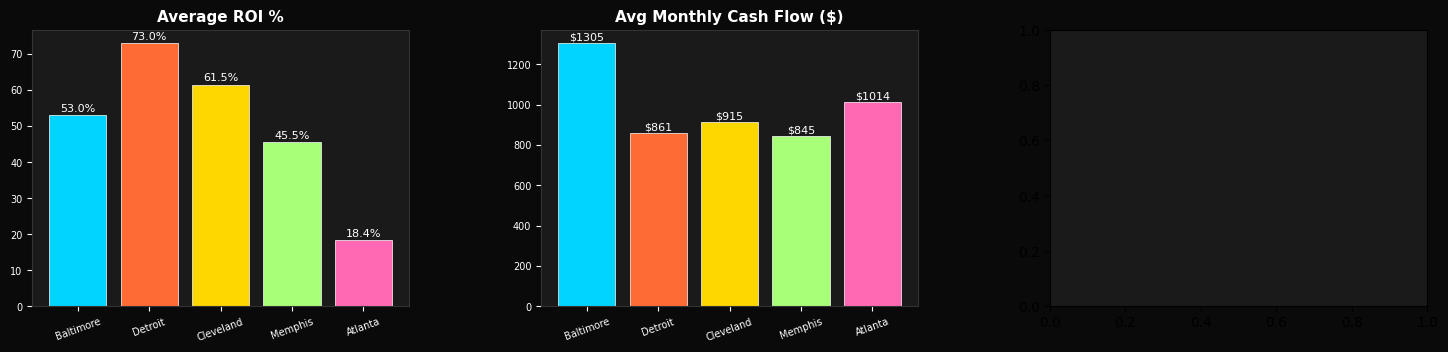

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Color scheme
city_colors = {
    'Baltimore': '#00d4ff',
    'Detroit':   '#ff6b35',
    'Cleveland': '#ffd700',
    'Memphis':   '#a8ff78',
    'Atlanta':   '#ff69b4'
}

city_order = ['Baltimore', 'Detroit', 'Cleveland', 'Memphis', 'Atlanta']
colors = [city_colors[c] for c in city_order]

# 1. Average ROI by city
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a1a')
roi_by_city = for_sale.groupby('city')['roi_pct'].mean().reindex(city_order)
bars = ax1.bar(city_order, roi_by_city, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Average ROI %', color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='white', labelsize=7)
ax1.set_xticklabels(city_order, rotation=20)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')
ax1.yaxis.label.set_color('white')
for bar, val in zip(bars, roi_by_city):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', color='white', fontsize=8)

# 2. Average Monthly Cash Flow
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a1a')
cf_by_city = for_sale.groupby('city')['monthly_cashflow'].mean().reindex(city_order)
bars2 = ax2.bar(city_order, cf_by_city, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Avg Monthly Cash Flow ($)', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='white', labelsize=7)
ax2.set_xticklabels(city_order, rotation=20)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')
for bar, val in zip(bars2, cf_by_city):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:.0f}', ha='center', va='bottom', color='white', fontsize=8)

# 3. Grade Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a1a')
grade_dist = for_sale.groupby('city')['grade'].value_counts().unstack(fill_value=0)
grade_colors = {'A': '#00ff88', 'B': '#00d4ff', 'C': '#ffd700', 'D': '#ff6b35', 'F': '#ff4444'}
bottom = np.zeros(len(city_order))
for grade in ['A', 'B', 'C', 'D', 'F']:
    if grade in grade_dist.columns:
        vals = [grade_dist.loc[c, grade] if c in grade_dist.index else 0 for c in city_order]

/tmp/ipykernel_55/112900552.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(city_order, rotation=20)
/tmp/ipykernel_55/112900552.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(city_order, rotation=20)
/tmp/ipykernel_55/112900552.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(city_order, rotation=20)
/tmp/ipykernel_55/112900552.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(city_order, rotation=20)


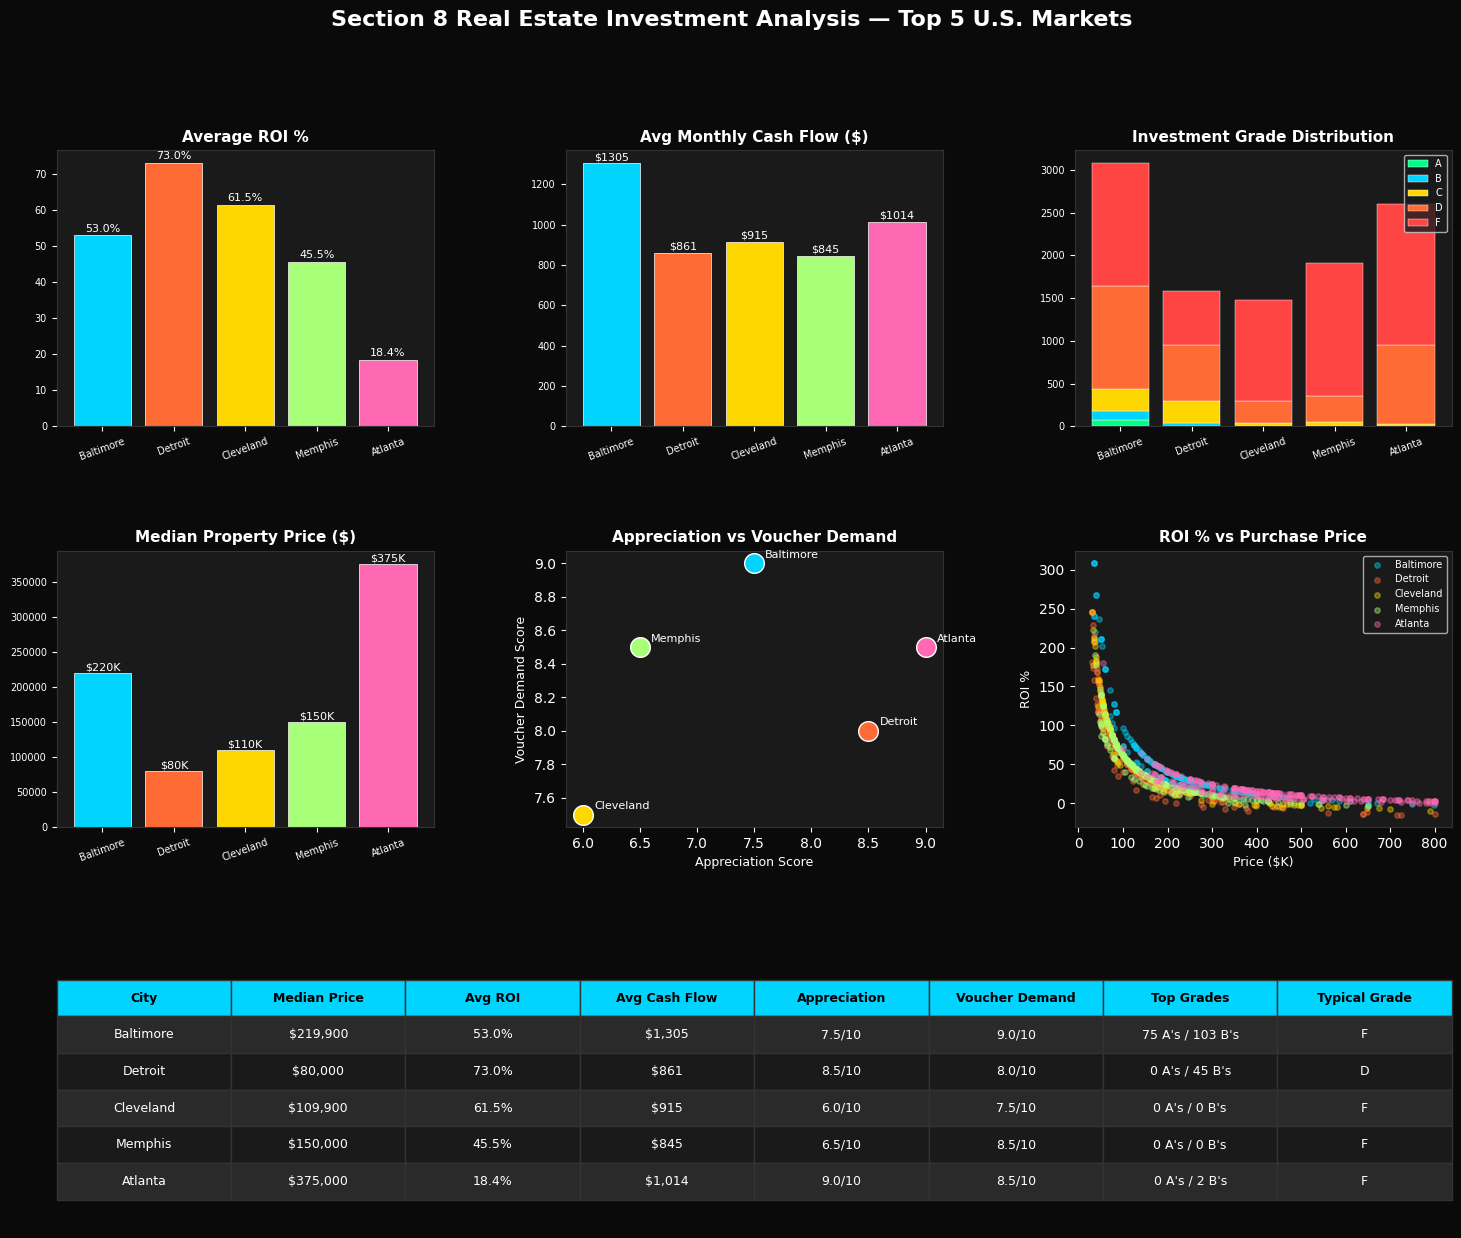

Report saved!


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Color scheme
city_colors = {
    'Baltimore': '#00d4ff',
    'Detroit':   '#ff6b35',
    'Cleveland': '#ffd700',
    'Memphis':   '#a8ff78',
    'Atlanta':   '#ff69b4'
}

city_order = ['Baltimore', 'Detroit', 'Cleveland', 'Memphis', 'Atlanta']
colors = [city_colors[c] for c in city_order]

# 1. Average ROI by city
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a1a')
roi_by_city = for_sale.groupby('city')['roi_pct'].mean().reindex(city_order)
bars = ax1.bar(city_order, roi_by_city, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Average ROI %', color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='white', labelsize=7)
ax1.set_xticklabels(city_order, rotation=20)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')
ax1.yaxis.label.set_color('white')
for bar, val in zip(bars, roi_by_city):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', color='white', fontsize=8)

# 2. Average Monthly Cash Flow
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a1a')
cf_by_city = for_sale.groupby('city')['monthly_cashflow'].mean().reindex(city_order)
bars2 = ax2.bar(city_order, cf_by_city, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Avg Monthly Cash Flow ($)', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='white', labelsize=7)
ax2.set_xticklabels(city_order, rotation=20)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')
for bar, val in zip(bars2, cf_by_city):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:.0f}', ha='center', va='bottom', color='white', fontsize=8)

# 3. Grade Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a1a')
grade_dist = for_sale.groupby('city')['grade'].value_counts().unstack(fill_value=0)
grade_colors = {'A': '#00ff88', 'B': '#00d4ff', 'C': '#ffd700', 'D': '#ff6b35', 'F': '#ff4444'}
bottom = np.zeros(len(city_order))
for grade in ['A', 'B', 'C', 'D', 'F']:
    if grade in grade_dist.columns:
        vals = [grade_dist.loc[c, grade] if c in grade_dist.index else 0 for c in city_order]
        ax3.bar(city_order, vals, bottom=bottom, label=grade,
                color=grade_colors[grade], edgecolor='white', linewidth=0.3)
        bottom += np.array(vals)
ax3.set_title('Investment Grade Distribution', color='white', fontsize=11, fontweight='bold')
ax3.tick_params(colors='white', labelsize=7)
ax3.set_xticklabels(city_order, rotation=20)
ax3.legend(loc='upper right', fontsize=7, facecolor='#1a1a1a', labelcolor='white')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

# 4. Average Property Price
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#1a1a1a')
price_by_city = for_sale.groupby('city')['price'].median().reindex(city_order)
bars4 = ax4.bar(city_order, price_by_city, color=colors, edgecolor='white', linewidth=0.5)
ax4.set_title('Median Property Price ($)', color='white', fontsize=11, fontweight='bold')
ax4.tick_params(colors='white', labelsize=7)
ax4.set_xticklabels(city_order, rotation=20)
for spine in ax4.spines.values():
    spine.set_edgecolor('#333')
for bar, val in zip(bars4, price_by_city):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val/1000:.0f}K', ha='center', va='bottom', color='white', fontsize=8)

# 5. Appreciation vs Voucher Demand scatter
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#1a1a1a')
for city in city_order:
    city_data = for_sale[for_sale['city'] == city].iloc[0]
    ax5.scatter(city_data['appreciation_score'], city_data['voucher_demand_score'],
                color=city_colors[city], s=200, zorder=5, edgecolors='white', linewidth=1)
    ax5.annotate(city, (city_data['appreciation_score'], city_data['voucher_demand_score']),
                 textcoords='offset points', xytext=(8, 4), color='white', fontsize=8)
ax5.set_title('Appreciation vs Voucher Demand', color='white', fontsize=11, fontweight='bold')
ax5.set_xlabel('Appreciation Score', color='white', fontsize=9)
ax5.set_ylabel('Voucher Demand Score', color='white', fontsize=9)
ax5.tick_params(colors='white')
for spine in ax5.spines.values():
    spine.set_edgecolor('#333')

# 6. ROI vs Price scatter
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1a1a')
for city in city_order:
    city_data = for_sale[for_sale['city'] == city]
    sample = city_data.sample(min(200, len(city_data)), random_state=42)
    ax6.scatter(sample['price']/1000, sample['roi_pct'],
                color=city_colors[city], alpha=0.4, s=15, label=city)
ax6.set_title('ROI % vs Purchase Price', color='white', fontsize=11, fontweight='bold')
ax6.set_xlabel('Price ($K)', color='white', fontsize=9)
ax6.set_ylabel('ROI %', color='white', fontsize=9)
ax6.tick_params(colors='white')
ax6.legend(fontsize=7, facecolor='#1a1a1a', labelcolor='white')
for spine in ax6.spines.values():
    spine.set_edgecolor('#333')

# 7. Summary table
ax7 = fig.add_subplot(gs[2, :])
ax7.set_facecolor('#0a0a0a')
ax7.axis('off')

summary_data = []
for city in city_order:
    city_df = for_sale[for_sale['city'] == city]
    a_count = len(city_df[city_df['grade'] == 'A'])
    b_count = len(city_df[city_df['grade'] == 'B'])
    summary_data.append([
        city,
        f"${city_df['price'].median():,.0f}",
        f"{city_df['roi_pct'].mean():.1f}%",
        f"${city_df['monthly_cashflow'].mean():,.0f}",
        f"{appreciation_scores[city]}/10",
        f"{voucher_demand_scores[city]}/10",
        f"{a_count} A's / {b_count} B's",
        city_df['grade'].mode()[0]
    ])

columns = ['City', 'Median Price', 'Avg ROI', 'Avg Cash Flow',
           'Appreciation', 'Voucher Demand', 'Top Grades', 'Typical Grade']

table = ax7.table(cellText=summary_data, colLabels=columns,
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#00d4ff')
        cell.set_text_props(color='black', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#1a1a1a')
        cell.set_text_props(color='white')
    else:
        cell.set_facecolor('#2a2a2a')
        cell.set_text_props(color='white')
    cell.set_edgecolor('#333333')

fig.suptitle('Section 8 Real Estate Investment Analysis — Top 5 U.S. Markets',
             color='white', fontsize=16, fontweight='bold', y=0.98)

plt.savefig('/kaggle/working/section8_investment_report.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("Report saved!")

In [10]:
import os
print("Output files:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

Output files:
  .virtual_documents — 4.0 KB
  section8_investment_report.png — 317.5 KB


In [11]:
# Save the cleaned dataset for the app
for_sale_export = for_sale[[
    'city', 'state', 'zip_code', 'price', 'bed', 'bath', 
    'house_size', 'street', 'monthly_rent', 'monthly_cashflow',
    'roi_pct', 'annual_tax', 'total_invested', 
    'investment_score', 'grade', 'appreciation_score', 
    'voucher_demand_score'
]].copy()

for_sale_export.to_csv('/kaggle/working/section8_data.csv', index=False)
print(f"Saved {len(for_sale_export)} properties")
print("Done!")

Saved 10645 properties
Done!
